**Ejemplo simple de un problema QP usando ADMM**

alejandro.garces@utp.edu.co

$\min \frac{1}{2}x^\top Q x $

$Ax\leq b$

In [1]:
using LinearAlgebra
using Plots
using JuMP
using Ipopt

In [10]:
n = 10  # numero de variables de decision
m = 6   # numero de restricciones
A = round.(randn(m,n)*2)
b = round.(randn(m)*100)
Q = (2*n)*I + rand(n,n) # me aseguro que sea diagonalmente dominante - semindefinida
Q = (Q+Q')/2
Modelo = Model(Ipopt.Optimizer)
@variable(Modelo,x[1:n])
@objective(Modelo,Min,1/2*x'*Q*x)
@constraint(Modelo,A*x<=b)
optimize!(Modelo)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:       53
Number of nonzeros in Lagrangian Hessian.............:       55

Total number of variables............................:       10
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        6
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        6

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 1.49e+02 1.01e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [11]:
xopt = value.(x)
round.(xopt,digits=3)

10-element Vector{Float64}:
  -2.202
  -1.867
   8.033
   4.671
  -9.445
  -9.23
  -1.486
   2.376
 -11.26
  -3.394

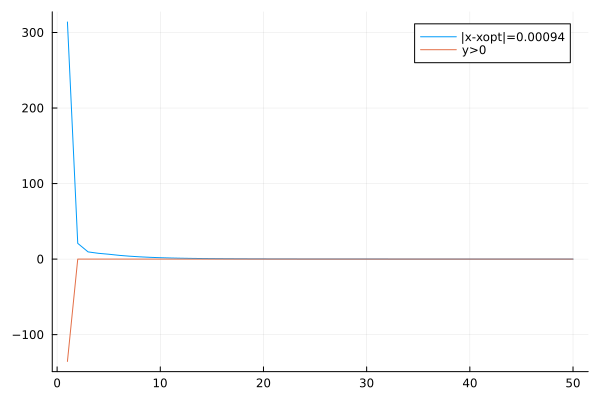

In [12]:
ρ = 1
h(u) = u>=0 ? u : 0;
argmin_f(u,x,y) = -1/ρ*(Q+1/ρ*A'*A)\(A'*(y-b+u))
argmin_g(u,x,y) = h.(b-u-A*x)
np = 50
x=100*randn(n,np)
y=100*randn(m,np)
u=100*randn(m,np)
for k = 2:np
    x[:,k] = argmin_f(u[:,k-1],x[:,k-1],y[:,k-1])
    y[:,k] = argmin_g(u[:,k-1],x[:,k]  ,y[:,k-1])    
    u[:,k] = u[:,k-1] + (A*x[:,k]+y[:,k]-b)
end
err_x = [norm(x[:,k]-xopt) for k = 1:np]
fac_y = [minimum(y[:,k]) for k = 1:np]
p = plot(err_x, label="|x-xopt|="*string(round.(err_x[np],digits=5)))
p = plot!(fac_y,label="y>0")
display(p)

In [13]:
[xopt x[:,np]]

10×2 Matrix{Float64}:
  -2.2023    -2.20264
  -1.86721   -1.86781
   8.03273    8.03245
   4.67148    4.67136
  -9.44504   -9.4453
  -9.22951   -9.22909
  -1.48596   -1.48611
   2.37585    2.37565
 -11.26     -11.2601
  -3.39377   -3.3937

In [14]:
y[:,np]

6-element Vector{Float64}:
   0.0
  62.15599342252183
 114.96919201948387
   0.0
  79.14534493126953
 204.22274922695684